In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

from lifelines import WeibullAFTFitter, LogNormalAFTFitter, LogLogisticAFTFitter, ExponentialFitter

/Users/manekoshkaryan/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/manekoshkaryan/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
data_raw = pd.read_csv('telco.csv')

In [3]:
def preprocess_data(df):
    df = df.copy().drop(columns=['ID'])
    categorical_cols = [
        'region', 'retire', 'marital', 'ed',
        'gender', 'voice', 'internet', 'forward',
        'custcat', 'churn'
    ]
    df_enc = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    df_enc = df_enc.rename(columns={'churn_Yes': 'churn'})
    return df_enc

In [4]:
df_mod = preprocess_data(data_raw)

In [5]:
models = {
    'Weibull': WeibullAFTFitter(),
    'Log-Normal': LogNormalAFTFitter(),
    'Log-Logistic': LogLogisticAFTFitter(),
    'Exponential': ExponentialFitter()
}

In [6]:
results = {}
for name, m in models.items():
    if isinstance(m, ExponentialFitter):
        m.fit(durations=df_mod['tenure'], event_observed=df_mod['churn'])
    else:
        m.fit(df_mod, duration_col='tenure', event_col='churn')
    print(f"\n{name} model summary:")
    m.print_summary()
    results[name] = {'model': m, 'AIC': m.AIC_}


Weibull model summary:


<lifelines.WeibullAFTFitter: fitted with 1000 total observations, 726 right-censored observations>
             duration col = 'tenure'
                event col = 'churn'
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1462.17
         time fit was run = 2025-05-01 17:09:19 UTC

---
                                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                                        
lambda_ address                          0.04      1.04      0.01            0.02            0.06                1.02                1.06
        age                              0.03      1.03      0.01            0.01            0.04                1.01                1.04
        custcat_E-service                0.98      2.66      0.16            0.67            1.28                1.96                3.61
        custcat_Plus service             0.74      2.10      0.19            0.36            1.12                1.44                3.06
        custcat_Total service            1.00      2.71      0.21            0.58            1.41                1.78                4.11
        ed_Did not complete high school  0.44      1.55      0.19            0.06            0.82                1.06                2.27
        ed_High school degree            0.32      1.38      0.15            0.03            0.61                1.03                1.83
        ed_Post-undergraduate degree     0.22      1.25      0.19           -0.15            0.60                0.86                1.82
        ed_Some college                  0.25      1.29      0.14           -0.03            0.54                0.97                1.71
        forward_Yes                     -0.10      0.91      0.15           -0.39            0.19                0.68                1.21
        gender_Male                      0.00      1.00      0.10           -0.20            0.21                0.82                1.23
        income                           0.00      1.00      0.00           -0.00            0.00                1.00                1.00
        internet_Yes                    -0.77      0.46      0.14           -1.04           -0.50                0.35                0.61
        marital_Unmarried               -0.35      0.71      0.10           -0.55           -0.14                0.58                0.87
        region_Zone 2                   -0.06      0.94      0.13           -0.31            0.19                0.73                1.21
        region_Zone 3                    0.12      1.12      0.13           -0.13            0.36                0.87                1.44
        retire_Yes                       0.17      1.19      0.52           -0.85            1.19                0.43                3.30
        voice_Yes                       -0.34      0.72      0.15           -0.63           -0.04                0.53                0.96
        Intercept                        2.78     16.14      0.27            2.25            3.31                9.48               27.47
rho_    Intercept                        0.17      1.19      0.05            0.07            0.27                1.08                1.32

                                         cmp to     z      p  -log2(p)
param   covariate                                                     
lambda_ address                            0.00  4.69 <0.005     18.47
        age                                0.00  4.12 <0.005     14.69
        custcat_E-service                  0.00  6.28 <0.005     31.44
        custcat_Plus service               0.00  3.83 <0.005     12.95
        custcat_Total service              0.00  4.67 <0.005     18.35
        ed_Did not complete high school    0.00  2.25   0.02      5.37
        ed_High school degree              0.00  2.19   0.03    


Log-Normal model summary:


<lifelines.LogNormalAFTFitter: fitted with 1000 total observations, 726 right-censored observations>
             duration col = 'tenure'
                event col = 'churn'
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1457.01
         time fit was run = 2025-05-01 17:09:20 UTC

---
                                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                                        
mu_    address                          0.04      1.04      0.01            0.03            0.06                1.03                1.06
       age                              0.03      1.03      0.01            0.02            0.05                1.02                1.05
       custcat_E-service                1.07      2.90      0.17            0.73            1.40                2.08                4.06
       custcat_Plus service             0.92      2.52      0.22            0.50            1.35                1.65                3.85
       custcat_Total service            1.20      3.32      0.25            0.71            1.69                2.03                5.42
       ed_Did not complete high school  0.37      1.45      0.20           -0.02            0.77                0.98                2.16
       ed_High school degree            0.32      1.37      0.16           -0.00            0.64                1.00                1.89
       ed_Post-undergraduate degree    -0.03      0.97      0.22           -0.47            0.40                0.62                1.50
       ed_Some college                  0.27      1.31      0.17           -0.05            0.60                0.95                1.82
       forward_Yes                     -0.20      0.82      0.18           -0.55            0.15                0.58                1.17
       gender_Male                      0.05      1.05      0.11           -0.17            0.28                0.84                1.32
       income                           0.00      1.00      0.00           -0.00            0.00                1.00                1.00
       internet_Yes                    -0.77      0.46      0.14           -1.05           -0.49                0.35                0.61
       marital_Unmarried               -0.46      0.63      0.12           -0.68           -0.23                0.51                0.80
       region_Zone 2                   -0.10      0.91      0.14           -0.38            0.18                0.69                1.20
       region_Zone 3                    0.05      1.05      0.14           -0.23            0.33                0.80                1.38
       retire_Yes                       0.02      1.02      0.44           -0.85            0.89                0.43                2.44
       voice_Yes                       -0.43      0.65      0.17           -0.76           -0.10                0.47                0.90
       Intercept                        2.36     10.61      0.29            1.79            2.94                5.98               18.84
sigma_ Intercept                        0.28      1.32      0.05            0.19            0.37                1.20                1.44

                                        cmp to     z      p  -log2(p)
param  covariate                                                     
mu_    address                            0.00  4.78 <0.005     19.11
       age                                0.00  4.50 <0.005     17.19
       custcat_E-service                  0.00  6.25 <0.005     31.21
       custcat_Plus service               0.00  4.29 <0.005     15.75
       custcat_Total service              0.00  4.79 <0.005     19.16
       ed_Did not complete high school    0.00  1.85   0.06      3.97
       ed_High school degree              0.00  1.94   0.05      4.24
       ed_Post-undergr


Log-Logistic model summary:


<lifelines.LogLogisticAFTFitter: fitted with 1000 total observations, 726 right-censored observations>
             duration col = 'tenure'
                event col = 'churn'
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1458.10
         time fit was run = 2025-05-01 17:09:21 UTC

---
                                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                                        
alpha_ address                          0.04      1.04      0.01            0.02            0.06                1.02                1.06
       age                              0.03      1.03      0.01            0.02            0.05                1.02                1.05
       custcat_E-service                1.04      2.83      0.17            0.72            1.36                2.05                3.91
       custcat_Plus service             0.86      2.37      0.21            0.45            1.27                1.57                3.57
       custcat_Total service            1.20      3.33      0.24            0.73            1.67                2.08                5.34
       ed_Did not complete high school  0.43      1.54      0.20            0.04            0.82                1.05                2.28
       ed_High school degree            0.34      1.40      0.15            0.03            0.64                1.03                1.89
       ed_Post-undergraduate degree    -0.02      0.98      0.22           -0.45            0.40                0.64                1.49
       ed_Some college                  0.24      1.27      0.16           -0.06            0.55                0.94                1.73
       forward_Yes                     -0.19      0.82      0.17           -0.53            0.14                0.59                1.15
       gender_Male                      0.04      1.04      0.11           -0.18            0.26                0.84                1.29
       income                           0.00      1.00      0.00           -0.00            0.00                1.00                1.00
       internet_Yes                    -0.80      0.45      0.14           -1.07           -0.52                0.34                0.60
       marital_Unmarried               -0.45      0.64      0.11           -0.66           -0.23                0.52                0.80
       region_Zone 2                   -0.05      0.95      0.14           -0.31            0.22                0.73                1.24
       region_Zone 3                    0.11      1.12      0.14           -0.15            0.38                0.86                1.46
       retire_Yes                       0.06      1.06      0.48           -0.87            1.00                0.42                2.71
       voice_Yes                       -0.40      0.67      0.16           -0.72           -0.08                0.49                0.92
       Intercept                        2.33     10.33      0.28            1.78            2.89                5.95               17.93
beta_  Intercept                        0.34      1.40      0.05            0.24            0.44                1.27                1.55

                                        cmp to     z      p  -log2(p)
param  covariate                                                     
alpha_ address                            0.00  4.42 <0.005     16.60
       age                                0.00  4.67 <0.005     18.36
       custcat_E-service                  0.00  6.30 <0.005     31.62
       custcat_Plus service               0.00  4.13 <0.005     14.74
       custcat_Total service              0.00  5.00 <0.005     20.73
       ed_Did not complete high school    0.00  2.18   0.03      5.11
       ed_High school degree              0.00  2.17   0.03      5.04
       ed_Post-under


Exponential model summary:


<lifelines.ExponentialFitter:"Exponential_estimate", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1606.98
               hypothesis = lambda_ != 0

---
          coef  se(coef)  coef lower 95%  coef upper 95%
lambda_ 129.66      7.83          114.30          145.01

         cmp to     z      p  -log2(p)
lambda_    0.00 16.55 <0.005    202.03
---
AIC = 3215.96


Best model: Log-Normal


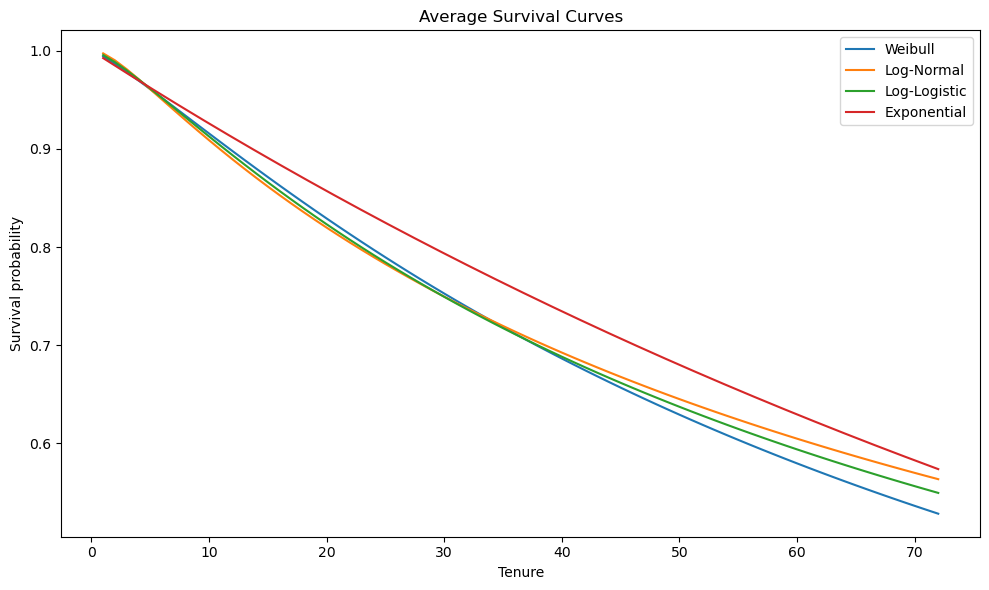

In [7]:
best = min(results, key=lambda k: results[k]['AIC'])
print(f"\nBest model: {best}")
plt.figure(figsize=(10,6))
for name, info in results.items():
    m = info['model']
    if isinstance(m, ExponentialFitter):
        surv = m.survival_function_
        mean_surv = surv.mean(axis=1)
        plt.plot(mean_surv.index, mean_surv.values, label=name)
    else:
        mean_surv = m.predict_survival_function(df_mod).mean(axis=1)
        plt.plot(mean_surv.index, mean_surv.values, label=name)
plt.xlabel('Tenure')
plt.ylabel('Survival probability')
plt.title('Average Survival Curves')
plt.legend()
plt.tight_layout()
plt.show()


In [8]:
best_model = results[best]['model']
sum_df = best_model.summary.reset_index()
main_param = [p for p in sum_df['param'].unique() if p != 'sigma_'][0]
sig_feats = sum_df[(sum_df['param']==main_param)&(sum_df['p']<0.05)]['covariate'].tolist()
sig_feats = [f for f in sig_feats if f!='Intercept']
print(f"Significant features: {sig_feats}")

Significant features: ['address', 'age', 'custcat_E-service', 'custcat_Plus service', 'custcat_Total service', 'internet_Yes', 'marital_Unmarried', 'voice_Yes']


In [9]:
df_final = df_mod[['tenure','churn']+sig_feats]
Final = type(best_model)()
if isinstance(Final, ExponentialFitter):
    Final.fit(durations=df_final['tenure'], event_observed=df_final['churn'])
else:
    Final.fit(df_final, duration_col='tenure', event_col='churn')
print("\nFinal model summary:")
print(Final.summary)



Final model summary:
                                  coef  exp(coef)  se(coef)  coef lower 95%  \
param  covariate                                                              
mu_    address                0.042824   1.043754  0.008847        0.025483   
       age                    0.036826   1.037512  0.006400        0.024283   
       custcat_E-service      1.025825   2.789395  0.169047        0.694499   
       custcat_Plus service   0.822553   2.276303  0.169425        0.490485   
       custcat_Total service  1.013269   2.754590  0.209579        0.602501   
       internet_Yes          -0.840528   0.431483  0.138259       -1.111511   
       marital_Unmarried     -0.447317   0.639341  0.114472       -0.671679   
       voice_Yes             -0.463493   0.629082  0.166771       -0.790359   
       Intercept              2.534887  12.615010  0.242611        2.059379   
sigma_ Intercept              0.283034   1.327150  0.046020        0.192836   

                             

In [10]:
surv_matrix = Final.predict_survival_function(df_final).T
annual_r = 0.10
monthly_r = (1+annual_r)**(1/12)-1
margin = 1000
weights = [1/((1+monthly_r)**t) for t in range(surv_matrix.shape[1])]
clv = surv_matrix.dot(weights) * margin

data_raw['CLV'] = clv.values

data_mod = df_mod.copy()
data_mod['CLV'] = clv.values


Average CLV by gender:
gender
Female    41546.825991
Male      41750.307070
Name: CLV, dtype: float64



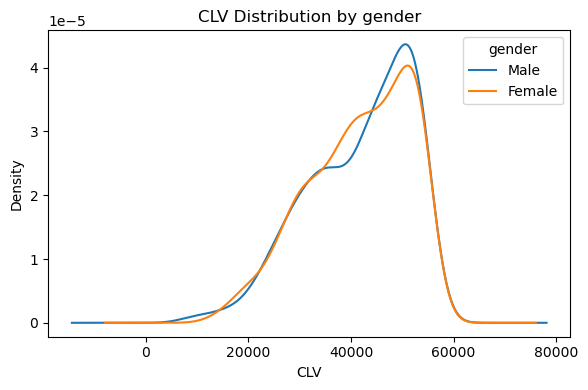

Average CLV by internet:
internet
No     45134.272751
Yes    35652.845038
Name: CLV, dtype: float64



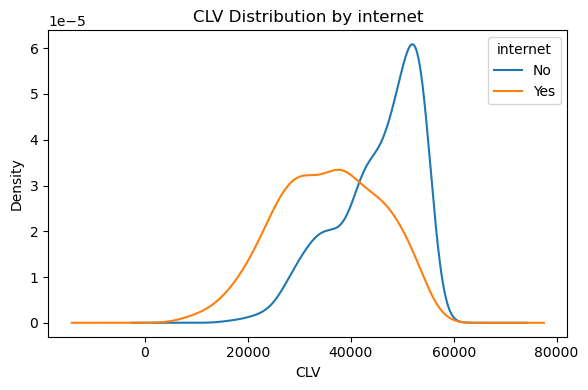

Average CLV by retire:
retire
No     41117.892936
Yes    52335.220952
Name: CLV, dtype: float64



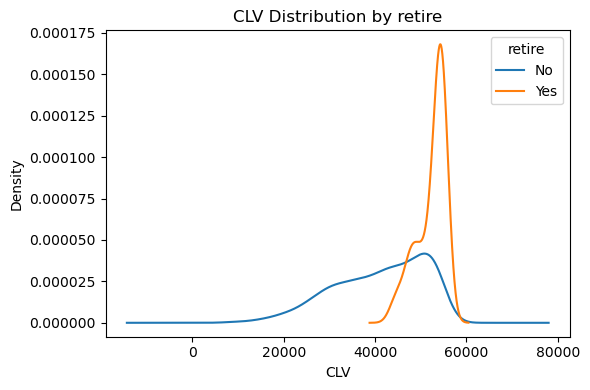

Average CLV by forward:
forward
No     40099.090377
Yes    43235.027447
Name: CLV, dtype: float64



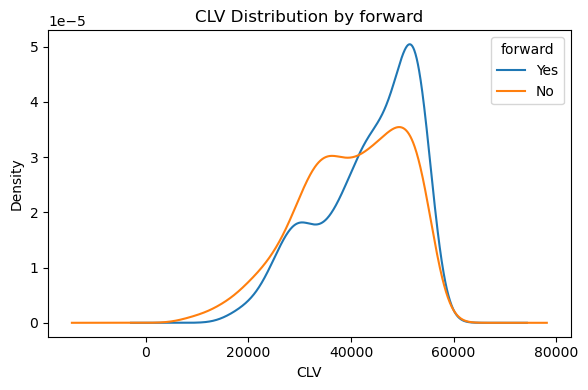

Average CLV by marital:
marital
Married      44023.953225
Unmarried    39313.367339
Name: CLV, dtype: float64



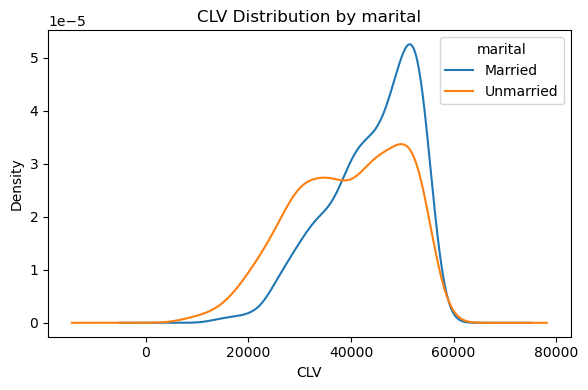

Average CLV by region:
region
Zone 1    41729.162682
Zone 2    42150.968874
Zone 3    41075.271409
Name: CLV, dtype: float64



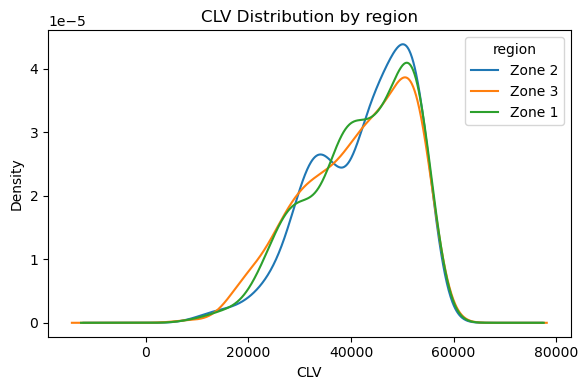

Average CLV by custcat:
custcat
Basic service    35216.177306
E-service        45027.172369
Plus service     47260.538722
Total service    39095.323746
Name: CLV, dtype: float64



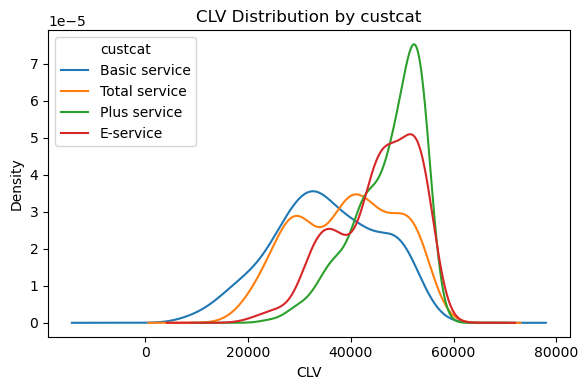

Average CLV by ed:
ed
College degree                  38883.427681
Did not complete high school    45638.242198
High school degree              42599.329453
Post-undergraduate degree       38581.280703
Some college                    40496.707116
Name: CLV, dtype: float64



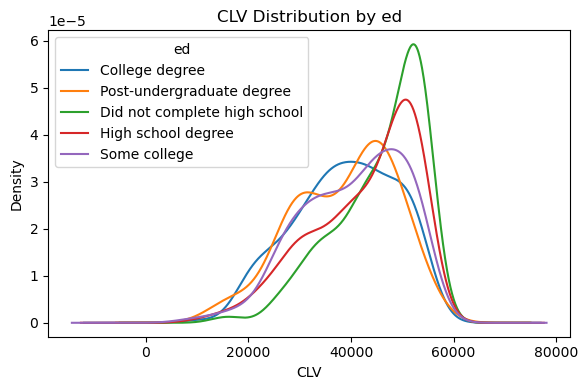

Average CLV by voice:
voice
No     43016.485854
Yes    38505.372362
Name: CLV, dtype: float64



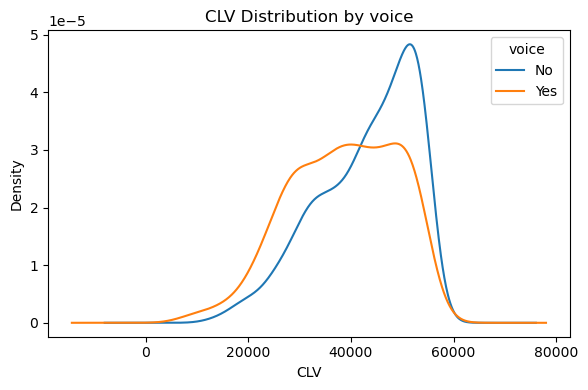

In [11]:
orig_cats = ['gender','internet','retire','forward','marital','region','custcat','ed','voice']
for col in orig_cats:
    if col in data_raw.columns:
        grp = data_raw.groupby(col)['CLV'].mean()
        print(f"Average CLV by {col}:\n{grp}\n")
        plt.figure(figsize=(6,4))
        for lvl in data_raw[col].unique():
            data_raw[data_raw[col]==lvl]['CLV'].plot(kind='density', label=str(lvl))
        plt.title(f'CLV Distribution by {col}')
        plt.xlabel('CLV')
        plt.legend(title=col)
        plt.tight_layout()
        plt.show()


In [12]:
df_mod['CLV'] = clv.values
maintained = df_mod[df_mod['churn']==0]
maintained_clv = maintained['CLV'].sum()
retention_rate = 0.8
cost_per_customer = 5000
retention_cost = len(df_mod) * retention_rate * cost_per_customer
annual_budget = maintained_clv - retention_cost
print(f"Annual retention budget: ${annual_budget:,.0f}")


Annual retention budget: $27,799,147


## Results

We chose the Log-Normal AFT model (AIC = 2954.02) because its “hump-shaped” hazard fits our data better than the steadily rising Weibull curve—early departures are heavier, then churn slows for long-standing subscribers. In this model, every extra year at the same address or of age extends expected tenure by about 3–4% (exp β ≈ 1.04 and 1.03). Upgrading from Basic to E-service, Plus, or Total bundles more than doubles or triples customer lifetime (exp β ≈ 2.5–3.3). On the flip side, simply adding internet service (exp β = 0.46), being unmarried (exp β = 0.63), or subscribing to voice (exp β = 0.65) shortens tenure by roughly 35–55%. Factors like education beyond high school, gender, and region made little difference once we account for these core drivers.

We define our most “valuable” subscribers as those with the highest projected lifetime value—retirees top the list at about 52 K  CLV, followed by Plus-plan users (47 K) and Basic-service customers without internet (45 K). To hold onto 80 percent of the at-risk group at 5 000 per person, we would budget around 27.8 million annually. To make the most of that spend, we recommend rolling out targeted loyalty perks (e.g. exclusive upgrades or referral bonuses) for retirees and premium-plan members, bundle discounts for unmarried internet and voice users to slow their early churn, and a first-year engagement program—welcome calls or usage rewards—to anchor new customers. These focused moves, guided by our Log-Normal survival curves, will help protect CLV without blowing the budget.
